<div style="background-color:#00843D;padding:22px 28px;border-radius:12px">
  <h2 style="color:white;margin:0;font-size:22px">Analisis Numerico</h2>
  <p style="color:#b8f0c8;margin:6px 0 2px;font-size:14px">Universidad Nacional de Colombia - Sede Manizales
  </p>
  <p style="color:#b8f0c8;margin:0;font-size:14px">Prof. Carlos Manuel Orrego Franco</p>
</div>

---

# Notebook 05: Del Paper a la Implementacion
## MLP, ResNet, RK-Net y la conexion con las Neural ODEs

---

### Objetivos de aprendizaje

1. **Explicar** por que ResNet es equivalente al metodo de Euler
2. **Explicar** por que RK-Net es equivalente al metodo RK4
3. **Implementar** los tres modelos (MLP, ResNet, RK-Net) en Keras
4. **Reproducir** la Tabla 1 del paper Chen et al. (2018) en MNIST
5. **Describir** la Neural ODE y su diferencia con RK-Net

---

> Las celdas **[OK]** estan listas con `Shift+Enter`. Las **[Ejercicio]** son para completar.


## 1. El cierre del circulo

En el Notebook 01 resolvimos EDOs con RK4:

$$\mathbf{y}_{n+1} = \mathbf{y}_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

En el Notebook 03 vimos como ResNet transforma su entrada capa por capa:

$$\mathbf{h}_{t+1} = \mathbf{h}_t + f(\mathbf{h}_t,\, \theta_t)$$

Chen et al. (2018) preguntaron:

> *"Si las capas de ResNet son pasos de Euler, que pasa si usamos*
> *un solver de EDOs adaptativo en su lugar?"*

La respuesta es la **Neural ODE**. Hoy vamos a recorrer ese argumento
paso a paso y reproducir sus resultados.


In [ ]:
# [OK] Imports

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import tensorflow as tf
from tensorflow import keras

plt.rcParams.update({
    "figure.dpi": 120, "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fafafa",
    "axes.grid": True, "grid.alpha": 0.3, "lines.linewidth": 2.0,
})

VERDE = "#00843D"; AZUL = "#1a5fa8"; ROJO = "#c0392b"
NARANJA = "#e67e22"; MORADO = "#8e44ad"; GRIS = "#7f8c8d"

tf.random.set_seed(42); np.random.seed(42)
print("Librerias cargadas.")


Librerias cargadas.


## 2. ResNet como metodo de Euler

He et al. (2015) introdujeron el **bloque residual**:

$$\mathbf{h}_{t+1} = \mathbf{h}_t + f(\mathbf{h}_t,\, \theta_t)$$

| Metodo de Euler | ResNet |
|-----------------|--------|
| $\mathbf{y}_{n+1} = \mathbf{y}_n + h\,f(\mathbf{y}_n, t_n)$ | $\mathbf{h}_{t+1} = \mathbf{h}_t + f(\mathbf{h}_t, \theta_t)$ |
| $f$ = derivada del sistema | $f$ = bloque neuronal (aprende la correccion) |
| $h$ = paso de tiempo | $h = 1$ (fijo entre capas) |

**Cada capa de ResNet es un paso de Euler con $h=1$.**
Una ResNet de $T$ capas integra con $T$ pasos de Euler.

Euler tiene error global $O(h)$: necesitas muchas capas para ser preciso.


## 3. RK-Net: usar RK4 dentro de la red

Si ResNet es Euler, la mejora natural es un integrador de mayor orden.
**RK-Net** implementa un paso de RK4 con la misma red $f_\theta$:

$$k_1 = f(\mathbf{h}_t,\;\theta), \quad
k_2 = f(\mathbf{h}_t+\tfrac{h}{2}k_1,\;\theta), \quad
k_3 = f(\mathbf{h}_t+\tfrac{h}{2}k_2,\;\theta), \quad
k_4 = f(\mathbf{h}_t+h\,k_3,\;\theta)$$

$$\mathbf{h}_{t+1} = \mathbf{h}_t + \frac{h}{6}(k_1+2k_2+2k_3+k_4)$$

| | ResNet | RK-Net |
|-|--------|--------|
| Pesos | Distintos por capa | Compartidos en todos los bloques |
| Evaluaciones de $f$ por paso | 1 | 4 |
| Equivalente a | Euler | RK4 |

### Y la Neural ODE?

$$\frac{d\mathbf{h}(t)}{dt} = f(\mathbf{h}(t),\, t,\, \theta)$$

La transformacion entrada->salida es la solucion de esta EDO de $t=0$ a $t=1$,
integrada por un **solver adaptativo** con paso variable -- igual que los solvers
para sistemas stiff del Notebook 01.


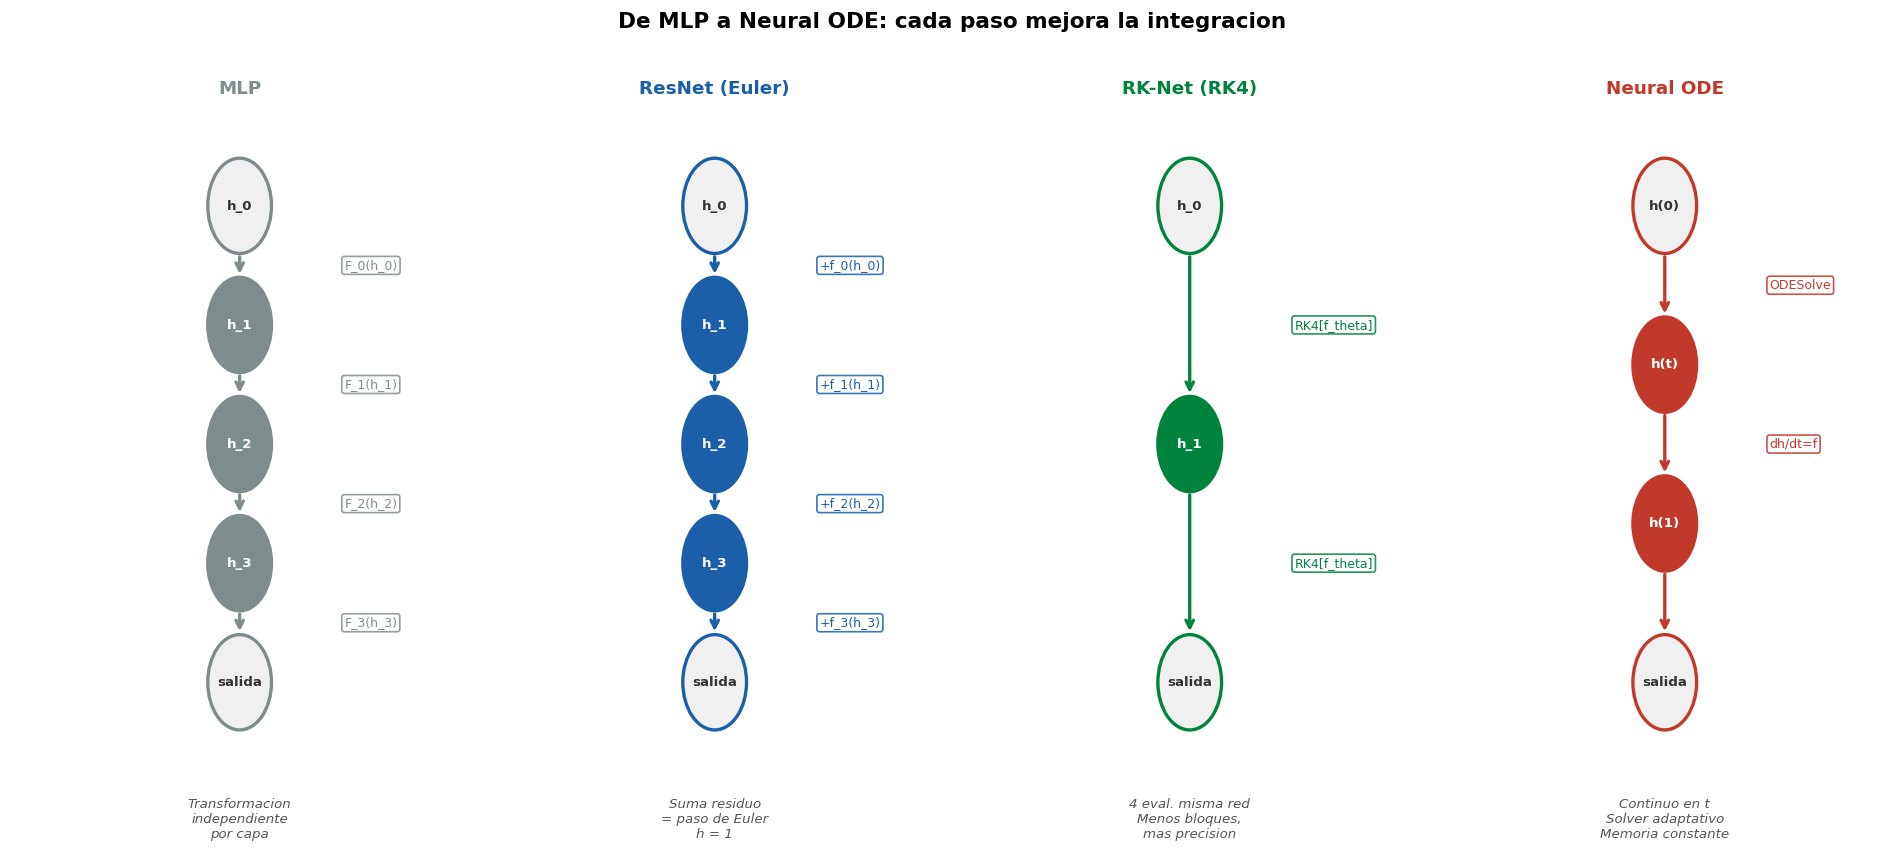

In [ ]:
# [OK] La jerarquia MLP -> ResNet -> RK-Net -> Neural ODE

fig, axes = plt.subplots(1, 4, figsize=(16, 7))
fig.patch.set_facecolor("white")

diag = [
    ("MLP",          GRIS,  ["h_0","h_1","h_2","h_3","salida"],
     ["F_0(h_0)","F_1(h_1)","F_2(h_2)","F_3(h_3)"],
     "Transformacion\nindependiente\npor capa"),
    ("ResNet (Euler)", AZUL, ["h_0","h_1","h_2","h_3","salida"],
     ["+f_0(h_0)","+f_1(h_1)","+f_2(h_2)","+f_3(h_3)"],
     "Suma residuo\n= paso de Euler\nh = 1"),
    ("RK-Net (RK4)",  VERDE, ["h_0","h_1","salida"],
     ["RK4[f_theta]","RK4[f_theta]"],
     "4 eval. misma red\nMenos bloques,\nmas precision"),
    ("Neural ODE",    ROJO,  ["h(0)","h(t)","h(1)","salida"],
     ["ODESolve","dh/dt=f"],
     "Continuo en t\nSolver adaptativo\nMemoria constante"),
]

for ax, (nombre, color, nodos, conex, nota) in zip(axes, diag):
    ax.set_facecolor("white"); ax.axis("off")
    n = len(nodos)
    ys = np.linspace(0.85, 0.15, n)
    for i, (y, label) in enumerate(zip(ys, nodos)):
        fc = color if 0 < i < n-1 else "#f0f0f0"
        ax.add_patch(plt.Circle((0.5, y), 0.07, transform=ax.transAxes,
                                 facecolor=fc, edgecolor=color, linewidth=2, zorder=3))
        tc = "white" if 0 < i < n-1 else "#333"
        ax.text(0.5, y, label, ha="center", va="center", fontsize=8,
                color=tc, fontweight="bold", transform=ax.transAxes)
    for i in range(n-1):
        ax.annotate("", xy=(0.5, ys[i+1]+0.07), xytext=(0.5, ys[i]-0.07),
                     xycoords="axes fraction",
                     arrowprops=dict(arrowstyle="->", color=color, lw=2))
        if i < len(conex):
            ymid = (ys[i]+ys[i+1])/2
            ax.text(0.73, ymid, conex[i], ha="left", va="center", fontsize=7.5,
                    color=color, transform=ax.transAxes,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                              edgecolor=color, alpha=0.85))
    ax.set_title(nombre, fontsize=11, fontweight="bold", color=color, pad=6)
    ax.text(0.5, -0.02, nota, ha="center", va="top", fontsize=8,
            color="#555", transform=ax.transAxes, style="italic")

plt.suptitle("De MLP a Neural ODE: cada paso mejora la integracion",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


In [ ]:
# [OK] Cargar y preparar MNIST

(X_tr2d, y_train), (X_te2d, y_test) = keras.datasets.mnist.load_data()
X_tr2d = X_tr2d.astype("float32") / 255.0
X_te2d = X_te2d.astype("float32") / 255.0
X_train = X_tr2d.reshape(-1, 784)
X_test  = X_te2d.reshape(-1, 784)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 784)  y_train: (60000,)
X_test:  (10000, 784)   y_test:  (10000,)


## 4. Los tres modelos: implementacion en Keras

Los tres modelos comparten la misma estructura de entrada y salida:

1. **Proyeccion**: 784 -> 64 dimensiones (Dense + tanh)
2. **Bloque de procesamiento**: diferente en cada modelo
3. **Clasificacion**: 64 -> 10 clases (softmax)

Esto garantiza una comparacion justa: la unica diferencia esta en el bloque central.


In [ ]:
# [Ejercicio 1] Implementar el MLP
#
# Arquitectura (del paper, Tabla 1):
#   Dense(64, tanh)  <- proyeccion
#   Dense(64, tanh)  <- capa oculta 1
#   Dense(64, tanh)  <- capa oculta 2
#   Dense(10, softmax)

def construir_mlp(dim=784, h=64, k=10):
    modelo = keras.Sequential([


        # [Ejercicio] Agrega los 4 layers
        keras.layers.Dense(h, "tanh", input_shape=(dim,)),
        keras.layers.Dense(h, "tanh"),
        keras.layers.Dense(h, "tanh"),
        keras.layers.Dense(k, "softmax"),
    ], name="MLP")
    return modelo

mlp = construir_mlp()
mlp.summary()

x_p = np.random.rand(1, 784).astype("float32")
try:
    out = mlp(x_p)
    print(f"\nSalida: {out.shape}  suma: {out.numpy().sum():.4f}")
except Exception as e:
    print(f"[!] {e}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,210 (231.29 KB)

 Trainable params: 59,210 (231.29 KB)

 Non-trainable params: 0 (0.00 B)


Salida: (1, 10)  suma: 1.0000


In [ ]:
# [Ejercicio 2] Implementar ResNet (bloque residual = paso de Euler)

class BloqueResidual(keras.layers.Layer):
    def __init__(self, unidades, **kwargs):
        super().__init__(**kwargs)
        self.d1 = keras.layers.Dense(unidades, activation="tanh")
        self.d2 = keras.layers.Dense(unidades, activation="tanh")  # sin activacion en la suma

    def call(self, h):
        # [Ejercicio] Implementa el bloque residual:
       #h_out = tanh(h + d2(d1(h)))
       p1= h+self.d2(self.d1(h)) # Paso 1: pasar h por d1, luego por d2
        # Paso 2: sumar el resultado a h
        # Paso 3: aplicar tanh a la suma
       return p1  # <- reemplaza con la implementacion

def construir_resnet(dim=784, h=64, n_bloques=2, k=10):
    entradas = keras.Input(shape=(dim,))
    x = keras.layers.Dense(h, activation="tanh")(entradas)
    for _ in range(n_bloques):
        x = BloqueResidual(h)(x)
    salidas = keras.layers.Dense(k, activation="softmax")(x)
    return keras.Model(entradas, salidas, name="ResNet")

resnet = construir_resnet()
resnet.summary()

try:
    out_r = resnet(x_p)
    print(f"\nSalida ResNet: {out_r.shape}  suma: {out_r.numpy().sum():.4f}")
except Exception as e:
    print(f"[!] {e}")


Model: "ResNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque_residual                 │ (None, 64)             │         8,320 │
│ (BloqueResidual)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque_residual_1               │ (None, 64)             │         8,320 │
│ (BloqueResidual)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,530 (263.79 KB)

 Trainable params: 67,530 (263.79 KB)

 Non-trainable params: 0 (0.00 B)


Salida ResNet: (1, 10)  suma: 1.0000


In [ ]:
# [OK] Implementar RK-Net (dado -- observa la estructura)

class BloqueRK4(keras.layers.Layer):
    """Un bloque que realiza un paso de RK4 con una red f_theta compartida."""

    def __init__(self, unidades, h=1.0, **kwargs):
        super().__init__(**kwargs)
        self.h = h
        self.f = keras.Sequential([
            keras.layers.Dense(unidades, activation="tanh"),
            keras.layers.Dense(unidades, activation="tanh"),
        ])

    def call(self, y):
        h  = self.h
        k1 = self.f(y)
        k2 = self.f(y + (h/2.0)*k1)
        k3 = self.f(y + (h/2.0)*k2)
        k4 = self.f(y + h*k3)
        return y + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def construir_rknet(dim=784, h=64, n_bloques=1, k=10):
    entradas = keras.Input(shape=(dim,))
    x = keras.layers.Dense(h, activation="tanh")(entradas)
    for _ in range(n_bloques):
        x = BloqueRK4(h)(x)
    salidas = keras.layers.Dense(k, activation="softmax")(x)
    return keras.Model(entradas, salidas, name="RK-Net")

rknet = construir_rknet()
rknet.summary()

out_rk = rknet(x_p)
print(f"\nSalida RK-Net: {out_rk.shape}  suma: {out_rk.numpy().sum():.4f}")
print()
print("Observa: RK-Net tiene MENOS parametros que ResNet")
print("porque los bloques RK4 comparten los mismos pesos.")


Model: "RK-Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bloque_rk4 (BloqueRK4)          │ (None, 64)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,210 (231.29 KB)

 Trainable params: 59,210 (231.29 KB)

 Non-trainable params: 0 (0.00 B)


Salida RK-Net: (1, 10)  suma: 1.0000

Observa: RK-Net tiene MENOS parametros que ResNet
porque los bloques RK4 comparten los mismos pesos.


In [ ]:
# [OK] Entrenar los tres modelos y registrar resultados

def entrenar(modelo, X_tr, y_tr, X_te, y_te, epocas=10, batch=128, lr=1e-3):
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    t0 = time.time()
    hist = modelo.fit(X_tr, y_tr, epochs=epocas, batch_size=batch,
                       validation_data=(X_te, y_te), verbose=0)
    dt = time.time() - t0
    _, acc = modelo.evaluate(X_te, y_te, verbose=0)
    return hist, acc, modelo.count_params(), dt

resultados = {}

print("Entrenando MLP...")
tf.random.set_seed(42)
mlp2 = construir_mlp()
h_mlp, acc_mlp, p_mlp, t_mlp = entrenar(mlp2, X_train, y_train, X_test, y_test)
resultados["MLP"] = dict(acc=acc_mlp, params=p_mlp, tiempo=t_mlp, hist=h_mlp, color=GRIS)
print(f"  acc={acc_mlp:.4f}  params={p_mlp:,}  t={t_mlp:.1f}s")

print("Entrenando ResNet...")
tf.random.set_seed(42)
resnet2 = construir_resnet()
h_res, acc_res, p_res, t_res = entrenar(resnet2, X_train, y_train, X_test, y_test)
resultados["ResNet"] = dict(acc=acc_res, params=p_res, tiempo=t_res, hist=h_res, color=AZUL)
print(f"  acc={acc_res:.4f}  params={p_res:,}  t={t_res:.1f}s")

print("Entrenando RK-Net...")
tf.random.set_seed(42)
rknet2 = construir_rknet()
h_rk, acc_rk, p_rk, t_rk = entrenar(rknet2, X_train, y_train, X_test, y_test)
resultados["RK-Net"] = dict(acc=acc_rk, params=p_rk, tiempo=t_rk, hist=h_rk, color=VERDE)
print(f"  acc={acc_rk:.4f}  params={p_rk:,}  t={t_rk:.1f}s")

print("\nEntrenamiento completado.")


Entrenando MLP...
  acc=0.9660  params=59,210  t=26.6s
Entrenando ResNet...
  acc=0.9700  params=67,530  t=28.6s
Entrenando RK-Net...
  acc=0.9697  params=59,210  t=33.8s

Entrenamiento completado.


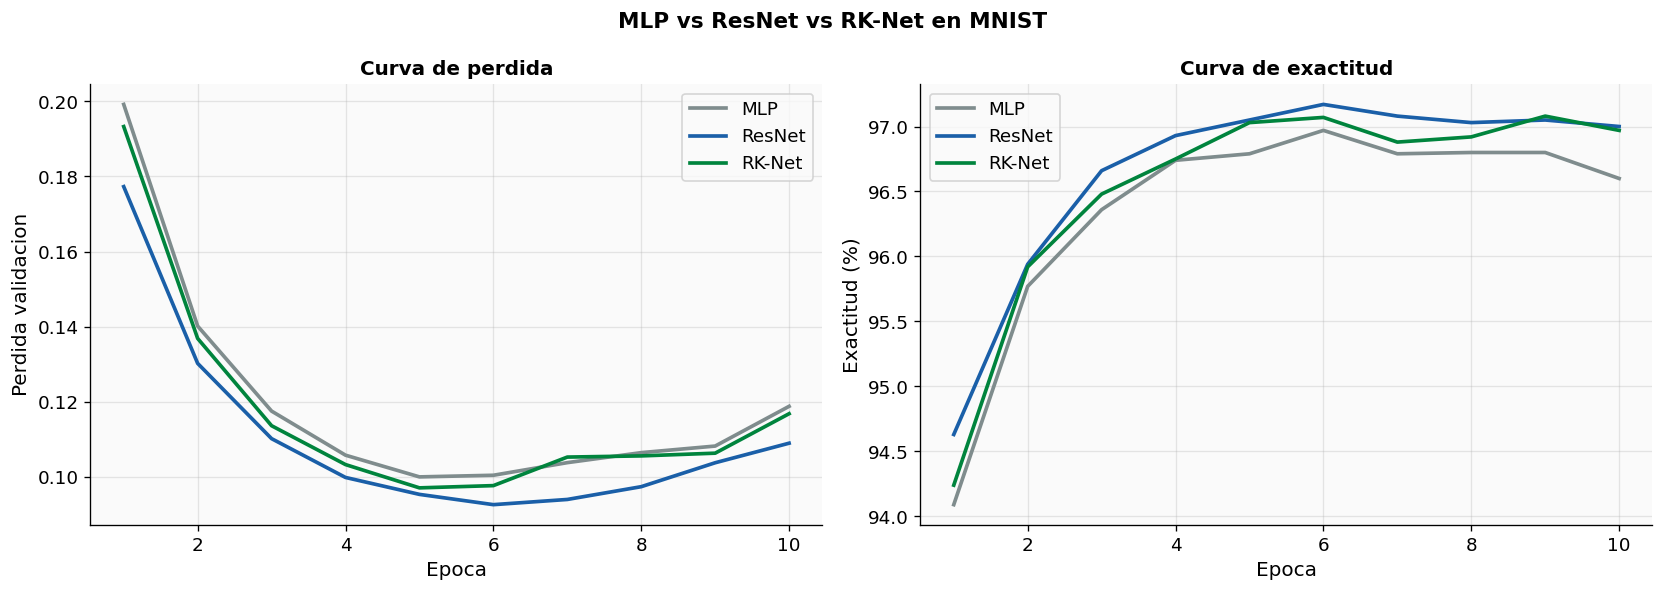

In [ ]:
# [OK] Comparar las curvas de aprendizaje

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nombre, datos in resultados.items():
    h   = datos["hist"]
    col = datos["color"]
    ep  = range(1, len(h.history["loss"])+1)
    axes[0].plot(ep, h.history["val_loss"],     color=col, lw=2.2, label=nombre)
    axes[1].plot(ep, [v*100 for v in h.history["val_accuracy"]], color=col, lw=2.2, label=nombre)

axes[0].set_xlabel("Epoca", fontsize=12); axes[0].set_ylabel("Perdida validacion", fontsize=12)
axes[0].set_title("Curva de perdida", fontsize=12, fontweight="bold"); axes[0].legend(fontsize=11)
axes[1].set_xlabel("Epoca", fontsize=12); axes[1].set_ylabel("Exactitud (%)", fontsize=12)
axes[1].set_title("Curva de exactitud", fontsize=12, fontweight="bold"); axes[1].legend(fontsize=11)
plt.suptitle("MLP vs ResNet vs RK-Net en MNIST", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


In [ ]:
# [OK] Reproducir la Tabla 1 del paper

# Resultados reportados en Chen et al. 2018 (Tabla 1)
err_paper  = {"MLP": 1.60, "ResNet": 0.61, "RK-Net": 0.47}
par_paper  = {"MLP": 167000, "ResNet": 206000, "RK-Net": 220000}

print("=" * 70)
print("  Tabla 1: MLP vs ResNet vs RK-Net en MNIST")
print("=" * 70)
header = "{:<10} {:>14} {:>12} {:>10} {:>8}".format(
    "Modelo", "Error nuestro", "Err. paper", "Params", "Tiempo")
print(header)
print("-" * 70)
for nombre in ["MLP", "ResNet", "RK-Net"]:
    d    = resultados[nombre]
    err  = (1 - d["acc"]) * 100
    ep   = err_paper[nombre]
    pp   = d["params"]
    tt   = d["tiempo"]
    fila = "{:<10} {:>12.2f}%  {:>10.2f}%  {:>9,}  {:>6.1f}s".format(
        nombre, err, ep, pp, tt)
    print(fila)
print("=" * 70)
print()
print("Error = tasa de error en test (100 - exactitud). Menor es mejor.")
print()
print("Diferencia con el paper: usan arquitectura ligeramente diferente.")
print("Lo importante es la TENDENCIA: RK-Net >= ResNet > MLP.")


  Tabla 1: MLP vs ResNet vs RK-Net en MNIST
Modelo      Error nuestro   Err. paper     Params   Tiempo
----------------------------------------------------------------------
MLP                3.40%        1.60%     59,210    26.6s
ResNet             3.00%        0.61%     67,530    28.6s
RK-Net             3.03%        0.47%     59,210    33.8s

Error = tasa de error en test (100 - exactitud). Menor es mejor.

Diferencia con el paper: usan arquitectura ligeramente diferente.
Lo importante es la TENDENCIA: RK-Net >= ResNet > MLP.


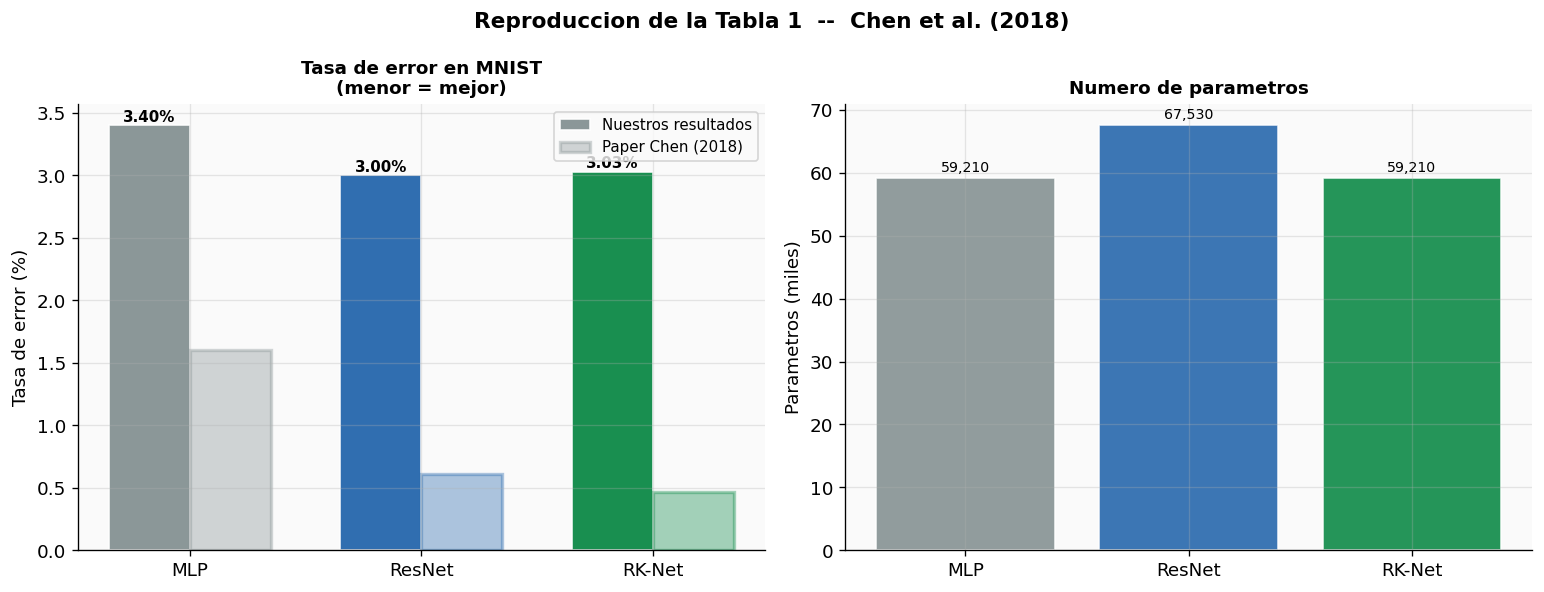

In [ ]:
# [OK] Visualizar la Tabla 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

nombres  = ["MLP", "ResNet", "RK-Net"]
colores  = [GRIS, AZUL, VERDE]
err_nos  = [(1-resultados[n]["acc"])*100 for n in nombres]
err_pap  = [err_paper[n] for n in nombres]
params   = [resultados[n]["params"] for n in nombres]

x = np.arange(3); w = 0.35
axes[0].bar(x - w/2, err_nos, w, color=colores, alpha=0.9,
             edgecolor="white", label="Nuestros resultados")
axes[0].bar(x + w/2, err_pap, w, color=colores, alpha=0.35,
             edgecolor=colores, linewidth=2, label="Paper Chen (2018)")
for i, (bar_x, v) in enumerate(zip(x - w/2, err_nos)):
    axes[0].text(bar_x, v + 0.03, f"{v:.2f}%",
                 ha="center", fontsize=9, fontweight="bold")
axes[0].set_xticks(x); axes[0].set_xticklabels(nombres, fontsize=11)
axes[0].set_ylabel("Tasa de error (%)", fontsize=11)
axes[0].set_title("Tasa de error en MNIST\n(menor = mejor)",
                   fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)

axes[1].bar(nombres, [p/1000 for p in params], color=colores,
             alpha=0.85, edgecolor="white")
for i, (name, p) in enumerate(zip(nombres, params)):
    axes[1].text(i, p/1000 + 1, f"{p:,}", ha="center", fontsize=8.5)
axes[1].set_ylabel("Parametros (miles)", fontsize=11)
axes[1].set_title("Numero de parametros", fontsize=11, fontweight="bold")

plt.suptitle("Reproduccion de la Tabla 1  --  Chen et al. (2018)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


In [ ]:
# [Ejercicio 3] Analizar los casos de desacuerdo entre modelos

y_pred_mlp = np.argmax(mlp2.predict(X_test, verbose=0), axis=1)
y_pred_res = np.argmax(resnet2.predict(X_test, verbose=0), axis=1)
y_pred_rk  = np.argmax(rknet2.predict(X_test, verbose=0), axis=1)

# Casos donde al menos dos modelos difieren
desacuerdo = np.where(
    (y_pred_mlp != y_pred_res) | (y_pred_res != y_pred_rk)
)[0]
print(f"Casos de desacuerdo: {len(desacuerdo):,} de {len(y_test):,}")
print()

# ================================================
# [Ejercicio] Completa el analisis:
# 1. ¿En cuantos casos SOLO MLP falla
#    (ResNet y RK-Net aciertan pero MLP no)?
# 2. ¿En cuantos casos los TRES fallan?
# Pista: usa mascaras booleanas de NumPy.
# ================================================
# 1. Solo MLP falla

solo_mlp_falla = (
    (y_pred_mlp != y_test) &
    (y_pred_res == y_test) &
    (y_pred_rk  == y_test)
)
# 2. Los tres fallan
todos_fallan   = (
    (y_pred_mlp != y_test) &
    (y_pred_res != y_test) &
    (y_pred_rk  != y_test)
)
  # define la mascara

if solo_mlp_falla is not None:
    print(f"Solo MLP falla (ResNet y RK-Net aciertan): {solo_mlp_falla.sum():,}")
    print(f"Los tres fallan: {todos_fallan.sum():,}")
else:
    print("[!] Completa el ejercicio para ver el analisis.")


Casos de desacuerdo: 466 de 10,000

Solo MLP falla (ResNet y RK-Net aciertan): 111
Los tres fallan: 121


## 5. Que es una Neural ODE de verdad?

Los modelos que implementamos son **discretizaciones** de una EDO.
La Neural ODE propuesta en el paper va un paso mas alla:
reemplaza el integrador discreto por un **solver continuo y adaptativo**.

```
ResNet / RK-Net:                    Neural ODE:

h_0 -> [bloque 1] ->                h(0) ──────────────────────> h(1)
h_1 -> [bloque 2] ->                      dh/dt = f(h(t), t, theta)
h_2 -> [bloque 3] ->                El solver elige el paso segun
h_3 -> [salida]                     la dificultad local (adaptativo)
```

### Las tres ventajas del paper

| Ventaja | Por que |
|---------|--------|
| **Memoria constante** | Backprop usa el metodo adjunto: no guarda activaciones intermedias |
| **Precision adaptativa** | Pasos pequenos donde la dinamica es rapida |
| **Modelos continuos** | Puede evaluar el estado en cualquier tiempo $t$ |

### La conexion con el Notebook 01

Recuerda el oscilador de Van der Pol con $\mu=10$: un sistema **stiff**
donde RK4 con paso fijo falla catastroficamente. Un solver adaptativo
usa pasos variables para navegar esa rigidez eficientemente.

La Neural ODE trae exactamente esa capacidad al aprendizaje profundo:
usa tantos pasos como necesite la dificultad del problema,
en vez de un numero fijo de capas.

> **El argumento central del paper:**
> ResNet con muchas capas es Euler con muchos pasos pequenos.
> Una Neural ODE puede lograr la misma precision con muchas menos
> evaluaciones de la red, usando pasos grandes donde la dinamica es suave.


## 6. Resumen del recorrido completo

### Lo que aprendimos en este notebook

| Concepto | Clave |
|----------|-------|
| **ResNet = Euler** | $h_{t+1} = h_t + f(h_t, \theta_t)$ es un paso de Euler |
| **RK-Net = RK4** | Evalua $f_\theta$ en 4 puntos por bloque, pesos compartidos |
| **Neural ODE** | Limite continuo: $dh/dt = f(h,t,\theta)$, solver adaptativo |
| **Metodo adjunto** | Backpropagation a traves del solver con memoria constante |
| **Tabla 1** | RK-Net >= ResNet > MLP en exactitud con parametros comparables |

---

### El recorrido completo

| NB | Inicio | Llegada |
|----|--------|---------|
| 01 | Neurona biologica (HH) | FitzHugh-Nagumo, RK4, diagrama de fases |
| 02 | Abstraccion McCulloch-Pitts | Perceptron, limites del modelo lineal |
| 03 | XOR sin solucion | Redes multicapa, backpropagation, Keras |
| 04 | Dataset en bruto | MNIST, clasificacion 97%+, lo que aprende la red |
| 05 | ResNet como Euler | RK-Net como RK4, Neural ODEs como EDOs continuas |

---

### Donde esta la investigacion hoy

El puente entre metodos numericos y aprendizaje profundo que inicio este paper
ha abierto lineas activas:

- **Series de tiempo irregulares:** datos que no llegan a intervalos regulares
- **Flujos normalizadores:** aprender distribuciones de probabilidad complejas
- **Dinamicas fisicas:** aprender las EDOs de sistemas mecanicos desde datos
- **Solvers neurales:** redes que aprenden a integrar EDOs mas eficientemente

Ahora tienen las herramientas para leer y entender los papers
que avanzan estos temas.

---

*Analisis Numerico  |  Universidad Nacional de Colombia  |  Prof. Carlos Manuel Orrego Franco*
